# 2. 시맨틱 세그멘테이션 데이터셋
Semantic Segmentation 학습을 위한 KITTI Dataset을 준비합니다.
# 3. 시맨틱 세그멘테이션 모델
U-Net model을 작성합니다.
# 4. 시맨틱 세그멘테이션 모델 시각화
학습된 결과를 시각화하면서, 모델의 최적 성능 지점을 정성적으로 평가할 수 있습니다.


# 실습목표
- 시맨틱 세그멘테이션 데이터셋을 전처리할 수 있습니다.
- 시맨틱 세그멘테이션 모델을 만들고 학습할 수 있습니다.
- 시맨틱 세그멘테이션 모델의 결과를 시각화할 수 있습니다.

# 2. 시맨틱 세그멘테이션 데이터셋
이미지, 데이터 가져오기
먼저 시맨틱 세그멘테이션(semantic segmentation) 으로 도로의 영역을 분리하기 위해서는 도로의 영역을 라벨로 가진 데이터셋을 가지고 학습할 수 있도록 파싱 해야 합니다. 아래 링크를 통해서 물체 검출(object detection)으로 사용했던 KITTI 데이터셋의 세그멘테이션 데이터 를 다운로드합니다. 

In [1]:
# !mkdir -p ~/work/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d work/semantic_segmentation/data/

--2026-07-06 07:09:12--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.139.60, 3.5.120.158, 3.5.134.235, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.139.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  16.5MB/s    in 20s     

2026-07-06 07:09:34 (15.3 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: work/semantic_segmentation/data/testing/
   creating: work/semantic_segmentation/data/testing/image_2/
  inflating: work/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: work/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: work/semantic_segmentation/data/testing/image_2/000002_10.png  
  inflating: work/sem

아래는 데이터셋에서 확인할 수있는 이미지와 라벨입니다. 지금까지 보던 라벨 데이터와 다르게 세그멘테이션 데이터는 이미지 형태의 라벨으로 되어있습니다.



[KITTI 데이터셋]
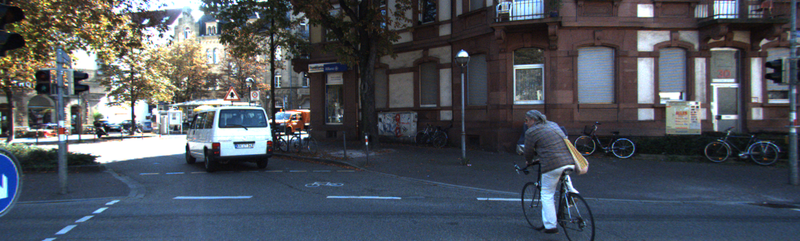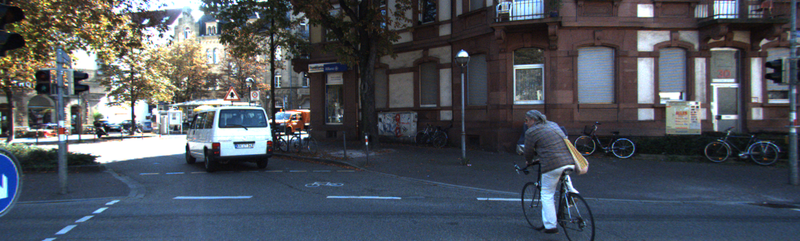


[KITTI 데이터셋 segmentation - raw 데이터이기때문에 변환이 필요합니다.]
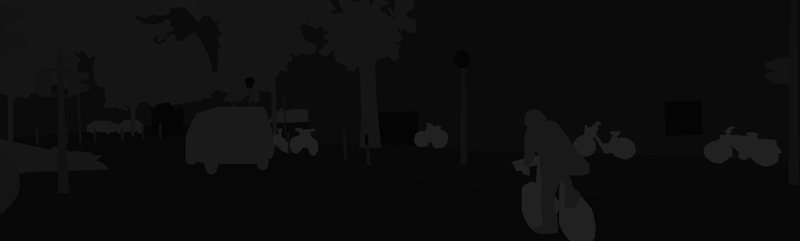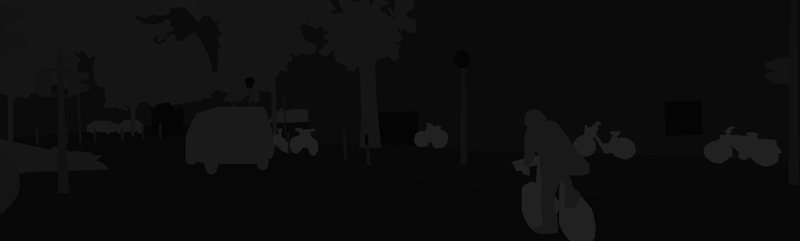

희미하게 뭔가 보이는 것 같으신가요?? 👀👀

[KITTI 데이터셋 segmentation_rgb]
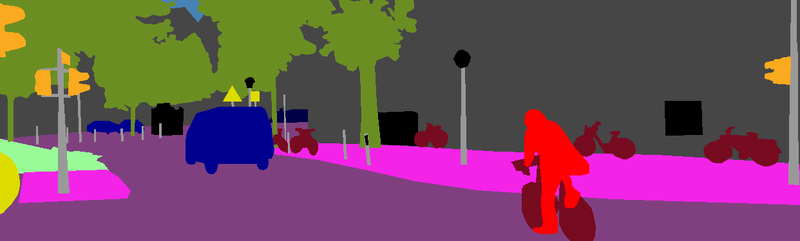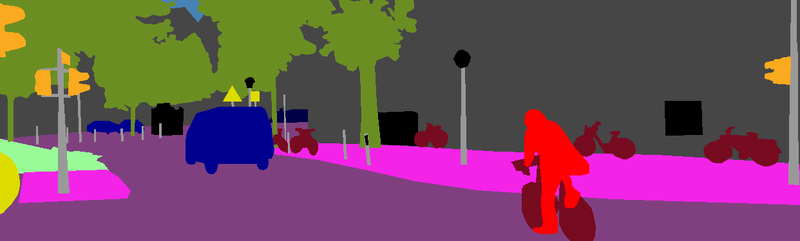

이제야 잘 보이네요!🤗

## 데이터 로더(data loader) 만들기
이제 이미지와 데이터셋이 주어졌으니 모델을 학습시킬 수 있는 데이터 로더(data loader)를 만들어봅시다. 로더는 입력값 (224, 224), 출력값 (224, 244) 크기를 갖는 모델을 학습시킬 수 있도록 데이터셋을 파싱 해야 합니다. 



이때 데이터 로더에 augmentation 을 적용해 봅시다. 오늘은 파이썬에서 많이 사용되는 albumentations을 사용해 보겠습니다. 하지만 Augmentation의 경우 imgaug 등 다른 라이브러리를 활용하셔도 됩니다.

In [1]:
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 54.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [albumentations]m [albumentations]eadless]


또한 학습셋의 일정량을 검증 데이터셋(validation dataset) 으로 활용할 수 있도록 해야 합니다. 



만든 후에는 직접 데이터셋이 잘 파싱 되어 나오는지 꼭 확인해보세요. 데이터셋에 오류가 없어야 성능이 안 나오더라도 문제를 찾아내기 쉽습니다.

In [35]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

print('=3')

=3


Albumentation 의 사용법을 간단히 알아보겠습니다. 아래는 Albumentation에서 다양한 augmentation 기법을 확률적으로 적용할 수 있게 해주는 Compose()의 활용예입니다. imgaug의 Sometimes()와 유사한 기능입니다.

In [36]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

/tmp/ipykernel_134/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


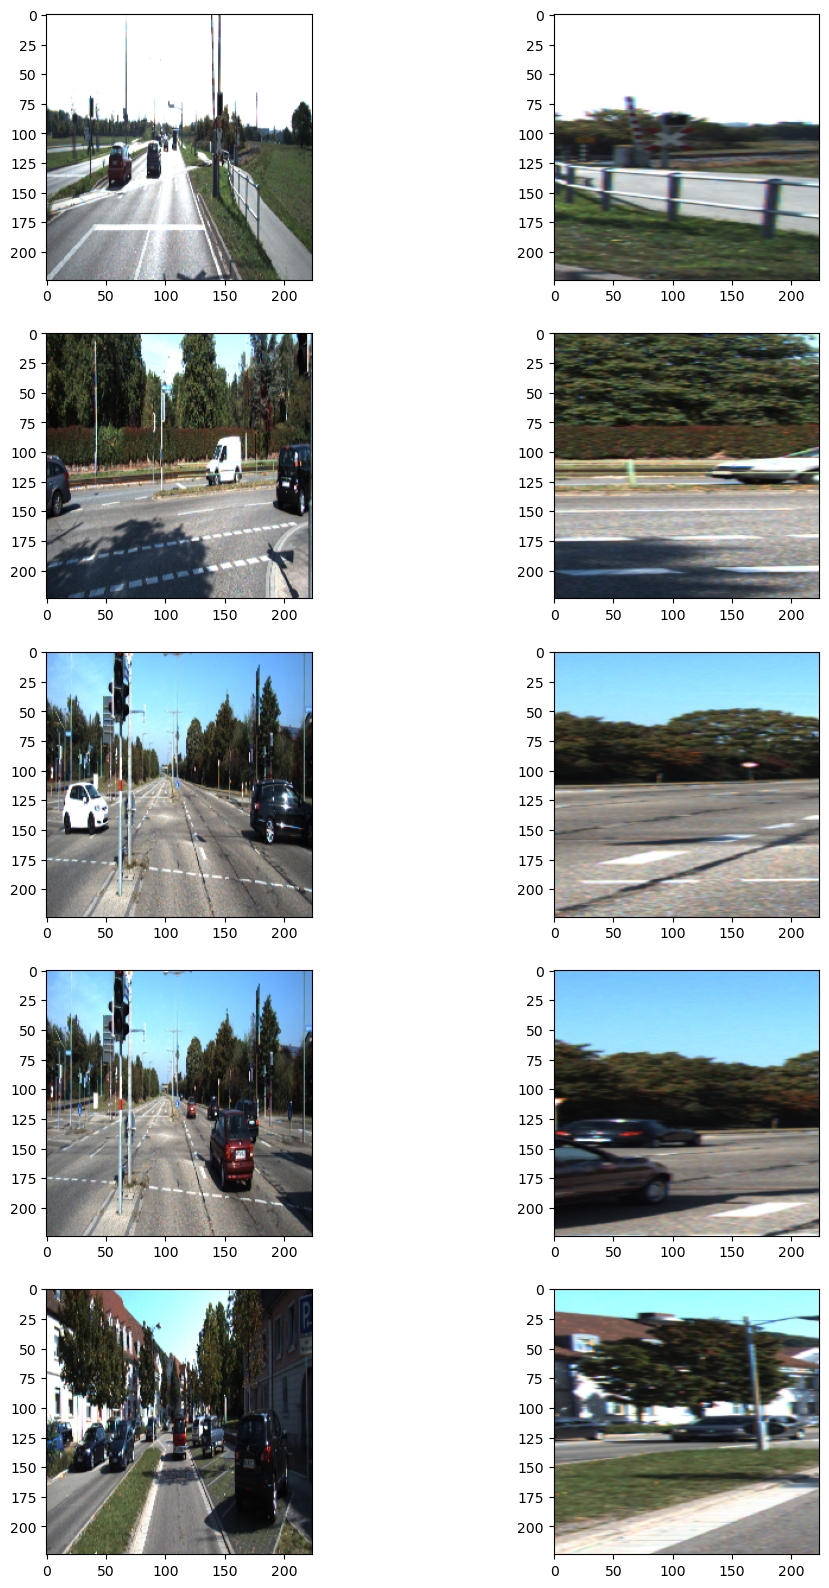

In [37]:
data_dir = "work/semantic_segmentation/data/training"

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

In [5]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [6]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    data_dir,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    data_dir,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

/tmp/ipykernel_134/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


# 3. 시맨틱 세그멘테이션 모델

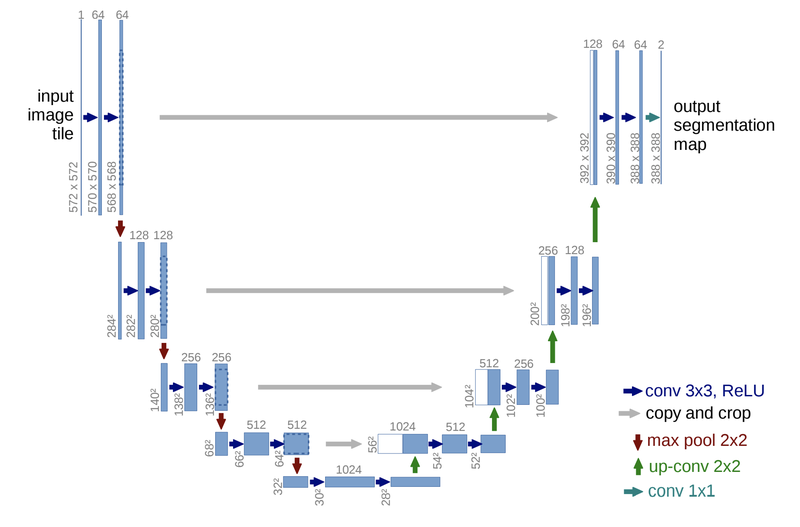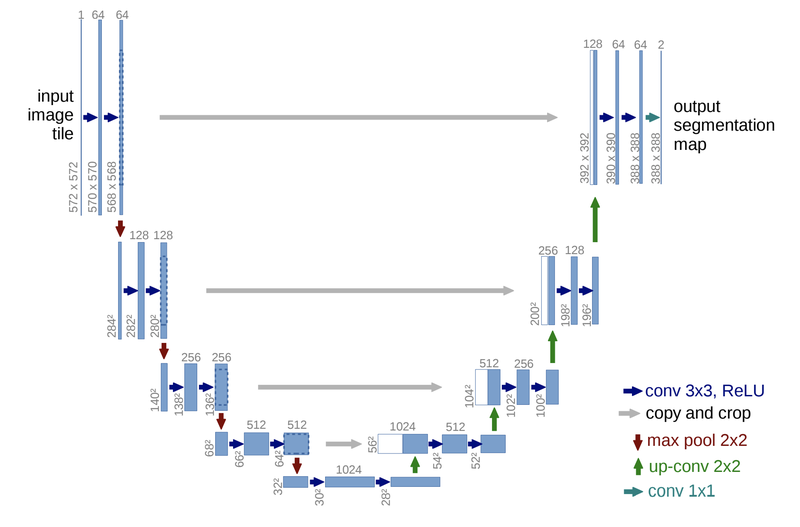

## 모델 구조 만들기
시맨틱 세그멘테이션을 위한 모델을 만들어주세요. 세그멘테이션 모델 중 구조상 비교적 구현이 단순한 U-Net을 구현해 봅시다. 



이때 입력 이미지의 크기는 위에서 만든 데이터셋에 맞춰서 만들어주세요. 



사용에 필요한 레이어와 연산은 다음과 같습니다. 그리고 필요에 따라서 Dropout 등의 다른 레이어를 적용해 보세요.


double_conv, MaxPool2d, Dropout, ConvTranspose2d, Conv2d, ReLU, bottleneck, cat, sigmoid
실행 되었습니다.



In [7]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

## 모델 학습하기
이제 모델을 만들었으니 위에서 만들어본 데이터셋과 학습을 해봅시다! (모델 학습에 상당한 시간이 소요됨으로 학습이 잘 진행되는지 확인해 보시고 다음 스텝으로 넘어가셔서 이미 학습된 모델을 사용하셔도 됩니다.)

In [9]:
%%time

# 모델 저장 경로
model_path = "./work/semantic_segmentation/seg_model_unet.pth"

# 모델 생성
model = UNet(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 손실 함수 및 옵티마이저 설정
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 데이터로더 준비
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.float())  # 타겟을 float 타입으로 변환
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

# 모델 저장
torch.save(model.state_dict(), model_path)

Epoch 1/100, Loss: 0.6933804154396057
Epoch 2/100, Loss: 0.6413162459026683
Epoch 3/100, Loss: 0.5727802406657826
Epoch 4/100, Loss: 0.49315782568671485
Epoch 5/100, Loss: 0.3841590474952351
Epoch 6/100, Loss: 0.3681666309183294
Epoch 7/100, Loss: 0.31949812173843384
Epoch 8/100, Loss: 0.27822383967312897
Epoch 9/100, Loss: 0.25883628021587024
Epoch 10/100, Loss: 0.22813871773806485
Epoch 11/100, Loss: 0.22678542814471506
Epoch 12/100, Loss: 0.22590801797129892
Epoch 13/100, Loss: 0.23423597623001446
Epoch 14/100, Loss: 0.26965179768475617
Epoch 15/100, Loss: 0.23500841043212198
Epoch 16/100, Loss: 0.2148909934542396
Epoch 17/100, Loss: 0.20617996698076074
Epoch 18/100, Loss: 0.18295463648709384
Epoch 19/100, Loss: 0.1872255951166153
Epoch 20/100, Loss: 0.18327440321445465
Epoch 21/100, Loss: 0.18989331207492136
Epoch 22/100, Loss: 0.1721071113239635
Epoch 23/100, Loss: 0.16303877600214697
Epoch 24/100, Loss: 0.19386229731819846
Epoch 25/100, Loss: 0.17395367270166223
Epoch 26/100, Los

# 4. 시맨틱 세그멘테이션 모델 시각화
이번에는 학습한 모델의 결과를 눈으로 확인해 볼 차례입니다. 우선 이전 스텝에서 저장한 모델이나 제공된 모델을 다음 코드를 통해 불러와 주세요.

In [9]:
model_path = "./work/semantic_segmentation/seg_model_unet.pth"
model = UNet(input_channels=3, output_channels=1)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # 평가 모드로 전환

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

테스트 셋은 이미지를 제공하지만 정답 데이터를 제공하지 않으니 눈으로 확인할 수 있도록 모델이 추론(inference)한 결과를 우리의 눈으로 볼 수 있는 세그멘테이션 이미지로 만들어주세요! 



이때 입력 이미지와 라벨을 한 번에 볼 수 있도록 모델의 출력값을 입력 이미지 위에 겹쳐서 보이기, 즉 오버레이(overray) 해 주세요. PIL 패키지를 사용하신다면 Image.blend를 활용하실 수 있습니다. 



get_output이라는 이름의 함수로 만들어 주세요.

In [10]:
import matplotlib.pyplot as plt

def get_output(model, preproc, image_path, output_path):
    # 원본 이미지 로드
    origin_img = imread(image_path)
    data = {"image": origin_img}

    # 전처리 적용
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # 모델 추론 (inference)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    # 시그모이드 활성화 후 임계값(0.5) 적용하여 바이너리 마스크 생성
    output = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255   #0.5라는 threshold를 변경하면 도로인식 결과범위가 달라집니다.
    output = Image.fromarray(output)

    # 배경과 결합하여 시각화 (Overlay)
    background = Image.fromarray(origin_img).convert('RGBA')
    output = output.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, output, alpha=0.5)

    # 변환된 이미지 저장
    blended.save(output_path)

    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)

    # 시각화
    plt.imshow(img_np)
    plt.axis('off')  # 축 제거 (옵션)
    plt.show()

    # blended.show()
    return blended

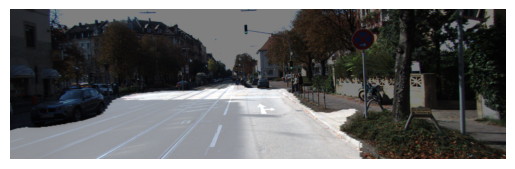

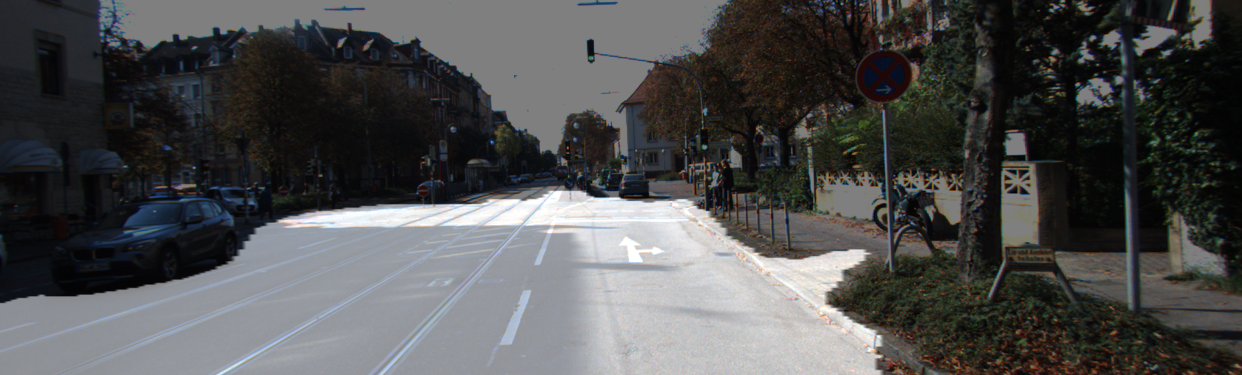

In [11]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
dir_path = './work/semantic_segmentation/data/training'
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png'
 )

세그멘테이션이 성능을 정량적으로 측정하기 위한 방법으로 IoU(Intersection over Union)를 계산하게 됩니다. IoU를 계산하는 방법은 지난 시간에 소개한 바 있으므로 해당 내용을 활용하여 구현해 보겠습니다. 



IoU를 계산하려면 모델이 도로 영역이라고 판단한 부분이 1로, 나머지 부분이 0으로 표시된 행렬, 그리고 라벨 데이터에서 도로 영역이 1, 나머지 부분이 0으로 표시된 행렬이 필요합니다. 각각을 prediction, target이라고 불렀을 때 이를 계산하는 함수를 구현해 보겠습니다. 위에 구현했던 get_output을 좀 더 확장해서 output, prediction, target을 함께 리턴하도록 구현해 봅시다.

In [12]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    union = np.logical_or(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    iou_score = intersection / (union + 1e-7)  # iou 스코어를 구하되 결과값을 float로 만들어주세요!
    print(f"IoU : {iou_score:.6f}")
    return iou_score

In [13]:
def get_output(model, preproc, image_path, output_path, label_path=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    prediction = Image.fromarray(prediction).convert('L')

    background = Image.fromarray(origin_img).convert('RGBA')
    prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)
    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)

    # 시각화
    plt.imshow(img_np)
    plt.axis('off')  # 축 제거 (옵션)
    plt.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        label_data = {"image": label_img}
        label_processed = preproc(**label_data)["image"]
        target = (label_processed == 7).astype(np.uint8) * 1

    return blended, np.array(prediction), target

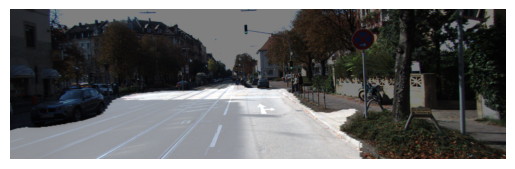

IoU : 0.906411


np.float64(0.9064105427674305)

In [14]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
output, prediction, target = get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
     label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'
 )

calculate_iou_score(target, prediction)

# 5. 프로젝트 : 개선된 U-Net 모델 만들기
U-Net을 통한 시맨틱 세그멘테이션 결과가 충분히 만족스러우신가요? 어느 정도 동작하는 것 같긴 하지만 좀 더 개선할 여지도 보일 것입니다.



2018년에 U-Net++라는 논문이 나왔습니다. 이 논문은 기존에 아주 단순하면서도 세그멘테이션에서 효과를 발휘했던 U-Net의 네트워크 구조에 DenseNet의 아이디어를 가미하여 성능을 개선한 모델입니다. 논문은 2020년에 한 번 업그레이드가 되었네요.



U-Net++: v1
U-Net++: v2

모델의 구조 자체는 아래 그림에서 보는 것처럼 별다른 설명이 없이도 직관적으로 이해가 가능한 수준입니다. 오늘 소개되었던 U-Net의 모델 코드를 조금만 수정 확장하면 충분히 구현할 수 있을 것입니다. 그래서 오늘의 과제는 바로 U-Net++ 모델을 스스로의 힘으로 직접 구현해 보고, U-Net을 활용했던 도로 세그멘테이션 태스크에 적용하여 U-Net을 썼을 때보다 성능이 향상되었음을 확인해 보는 것입니다. 정성적으로는 두 모델의 세그멘테이션 결과를 시각화해서 비교해 볼 수 있을 것이고, 정량적으로는 동일 이미지에 대한 IoU 값을 비교해 보면 될 것입니다.

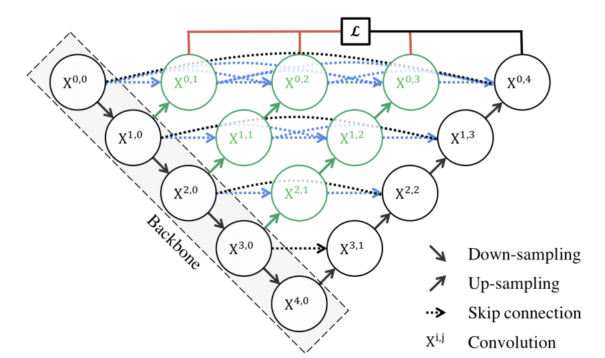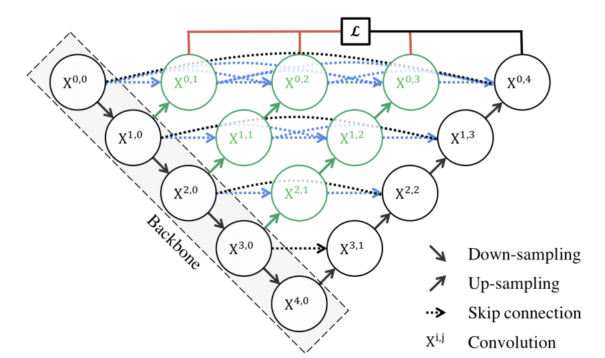

참고할 수 있는 코드는 아래에 있습니다. 다행히도 keras로 구현되어 있습니다.



U-Net++:Github

코드 중에서 가장 중요한 부분도 알려드리자면 여기:build_xnet입니다. 논문에서 제시하는 수식과 함께 참고하세요.

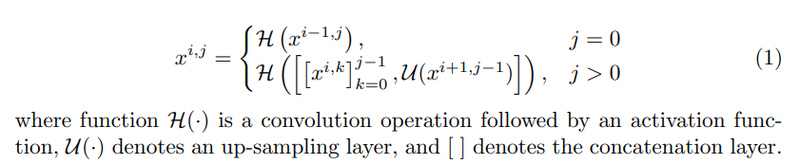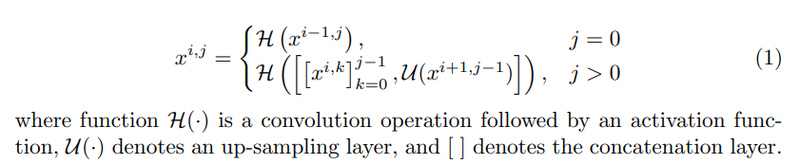

[H와 u와 []가 무엇인지 주목하세요]

코드 중 up_block으로는 두 가지 방식을 사용하고 있네요. Transpose2D_block과 Upsample2D_block인데요. 둘 중 어느 것을 사용해도 좋습니다.

또 한 가지 주의해야 할 점은 Loss를 조금 다르게 구현해야 한다는 점입니다. binary cross-entropy와 dice coefficient를 사용한다고 하는데요. dice_coef에 구현된 dice coefficient를 참고해 보세요.

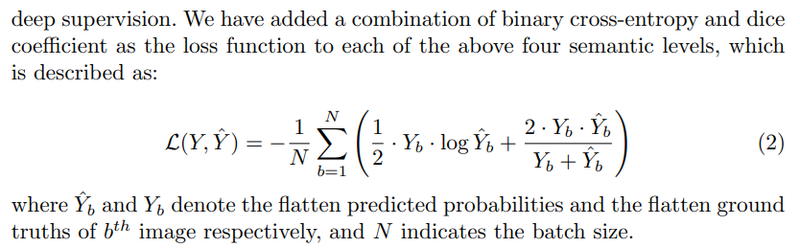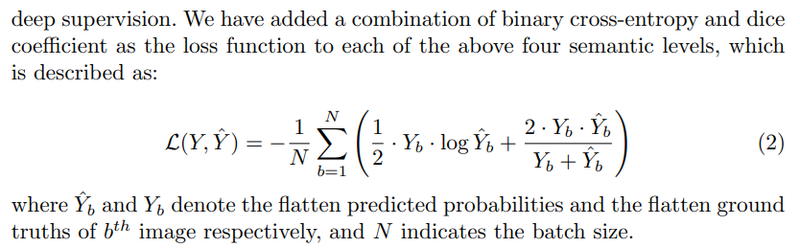

[binary cross-entropy와 dice coefficient를 이용합니다]

https://arxiv.org/pdf/1807.10165.pdf

프로젝트 진행에 필요한 주요 라이브러리 버전 체크를 해봅시다.

In [32]:
import torch
import numpy as np
import PIL
import skimage
import albumentations

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.7.1+cu118
2.2.6
11.2.1
0.25.2
2.0.8


## Step 1. KITTI 데이터셋 수집과 구축
다운로드한 KITTI 데이터에 data augmentation을 적용한 형태로 데이터셋을 구축합니다. 이때 주의할 점이 있습니다. U-Net++는 메모리 사용량이 U-Net보다 꽤 많아집니다. 그러니 배치 사이즈를 적절히 줄여서 설정하시기를 권합니다.


In [42]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

In [43]:
data_dir = "work/semantic_segmentation/data/training"

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

/tmp/ipykernel_134/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


In [44]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)


In [45]:
from torch.utils.data import DataLoader

print(dir_path)

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    data_dir,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    data_dir,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

./work/semantic_segmentation/data/training


/tmp/ipykernel_134/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop



## Step 2. U-Net++ 모델의 구현
U-Net의 모델 구조와 소스코드를 면밀히 비교해 보다 보면, U-Net++를 어떻게 구현할 수 있을지에 대한 방안을 떠올릴 수 있을 것입니다. 이 과정을 통해 U-Net 자체에 대한 이해도도 증진될 것입니다. 그 외 적절히 U-Net의 백본 구조, 기타 파라미터 변경 등을 통해 추가적인 성능 향상이 가능할 수도 있습니다.


In [46]:
import torch
import torch.nn as nn

class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

### 1) 오리지널 U-Net 구조

In [47]:
class UNet(nn.Module):
    def __init__(self, num_classes=1, input_channels=3):
        super().__init__()
        nb_filter = [32, 64, 128, 256, 512]

        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Encoder
        self.x0_0 = VGGBlock(input_channels, nb_filter[0])
        self.x1_0 = VGGBlock(nb_filter[0], nb_filter[1])
        self.x2_0 = VGGBlock(nb_filter[1], nb_filter[2])
        self.x3_0 = VGGBlock(nb_filter[2], nb_filter[3])
        self.x4_0 = VGGBlock(nb_filter[3], nb_filter[4])

        # Decoder
        self.x3_1 = VGGBlock(nb_filter[4] + nb_filter[3], nb_filter[3])
        self.x2_2 = VGGBlock(nb_filter[3] + nb_filter[2], nb_filter[2])
        self.x1_3 = VGGBlock(nb_filter[2] + nb_filter[1], nb_filter[1])
        self.x0_4 = VGGBlock(nb_filter[1] + nb_filter[0], nb_filter[0])

        self.final = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)

    def forward(self, x):
        x0_0 = self.x0_0(x)
        x1_0 = self.x1_0(self.pool(x0_0))
        x2_0 = self.x2_0(self.pool(x1_0))
        x3_0 = self.x3_0(self.pool(x2_0))
        x4_0 = self.x4_0(self.pool(x3_0))

        x3_1 = self.x3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.x2_2(torch.cat([x2_0, self.up(x3_1)], 1))
        x1_3 = self.x1_3(torch.cat([x1_0, self.up(x2_2)], 1))
        x0_4 = self.x0_4(torch.cat([x0_0, self.up(x1_3)], 1))

        return self.final(x0_4)

In [52]:
# --- 1. 모델, 손실함수, 옵티마이저 재선언 (U-Net 버전) ---
# 기존에 정의된 UNet 클래스를 호출합니다.
model_unet = UNet(num_classes=1, input_channels=3).to(device)

criterion = BCEDiceLoss(bce_weight=0.5)
optimizer_unet = optim.Adam(model_unet.parameters(), lr=lr)

print(f"Using device: {device} | Training Original U-Net...")

# --- 1. 하이퍼파라미터 및 환경 설정 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 20
batch_size = 4
lr = 1e-4


# --- 2. Training Loop ---
for epoch in range(epochs):
    model_unet.train()
    train_loss = 0.0
    train_iou = 0.0
    
    # 학습 단계
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train - UNet]")
    for images, masks in pbar:
        images = images.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)
        
        optimizer_unet.zero_grad()
        outputs = model_unet(images)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer_unet.step()
        
        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        
        pbar.set_postfix({
            'Loss': f"{loss.item():.4f}", 
            'IoU': f"{calculate_iou(outputs, masks):.4f}"
        })
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou = train_iou / len(train_loader)
    
    # 검증 단계 (Validation)
    model_unet.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)
            
            outputs = model_unet(images)
            loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    
    print(f"\n=> Epoch {epoch+1} Summary (U-Net)")
    print(f"   [Train] Loss: {avg_train_loss:.4f} | IoU: {avg_train_iou:.4f}")
    print(f"   [Val]   Loss: {avg_val_loss:.4f} | IoU: {avg_val_iou:.4f}\n")

# 학습 완료 후 가중치 저장 (U-Net++와 구분되도록 파일명 변경)
torch.save(model_unet.state_dict(), 'original_unet_kitti.pth')
print("Original U-Net model saved successfully as 'original_unet_kitti.pth'!")

Using device: cuda | Training Original U-Net...


Epoch 1/20 [Train - UNet]: 100%|██████████| 42/42 [00:06<00:00,  6.24it/s, Loss=0.5160, IoU=0.5725]



=> Epoch 1 Summary (U-Net)
   [Train] Loss: 0.5901 | IoU: 0.4464
   [Val]   Loss: 0.5426 | IoU: 0.5144



Epoch 2/20 [Train - UNet]: 100%|██████████| 42/42 [00:06<00:00,  6.31it/s, Loss=0.4574, IoU=0.6453]



=> Epoch 2 Summary (U-Net)
   [Train] Loss: 0.5271 | IoU: 0.5713
   [Val]   Loss: 0.4911 | IoU: 0.6691



...


=> Epoch 18 Summary (U-Net)
   [Train] Loss: 0.3537 | IoU: 0.7517
   [Val]   Loss: 0.3333 | IoU: 0.7402



Epoch 19/20 [Train - UNet]: 100%|██████████| 42/42 [00:06<00:00,  6.40it/s, Loss=0.4037, IoU=0.6764]



=> Epoch 19 Summary (U-Net)
   [Train] Loss: 0.3335 | IoU: 0.7739
   [Val]   Loss: 0.3540 | IoU: 0.7062



Epoch 20/20 [Train - UNet]: 100%|██████████| 42/42 [00:06<00:00,  6.34it/s, Loss=0.3821, IoU=0.6797]



=> Epoch 20 Summary (U-Net)
   [Train] Loss: 0.3403 | IoU: 0.7432
   [Val]   Loss: 0.3287 | IoU: 0.7298

Original U-Net model saved successfully as 'original_unet_kitti.pth'!


### 2) U-Net++ 구조 (Nested Dense Skip Connection)
U-Net++는 중간 노드(x0_1, x1_1, x0_2 등)들이 격자 형태로 촘촘하게 밀집 연결되어 구조적 공백을 메꿉니다. (Deep Supervision 기능은 단순 비교를 위해 선택적으로 꺼둘 수 있도록 기본 구조 위주로 정의합니다.)

In [48]:
class UNetPlusPlus(nn.Module):
    def __init__(self, num_classes=1, input_channels=3):
        super().__init__()
        nb_filter = [32, 64, 128, 256, 512]

        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Spine Nodes (L1, L2, L3, L4, L5 백본 축)
        self.x0_0 = VGGBlock(input_channels, nb_filter[0])
        self.x1_0 = VGGBlock(nb_filter[0], nb_filter[1])
        self.x2_0 = VGGBlock(nb_filter[1], nb_filter[2])
        self.x3_0 = VGGBlock(nb_filter[2], nb_filter[3])
        self.x4_0 = VGGBlock(nb_filter[3], nb_filter[4])

        # Nested Nodes (이 내부 밀집 연결로 인해 메모리 사용량이 크게 뜁니다)
        self.x0_1 = VGGBlock(nb_filter[0] + nb_filter[1], nb_filter[0])
        self.x1_1 = VGGBlock(nb_filter[1] + nb_filter[2], nb_filter[1])
        self.x2_1 = VGGBlock(nb_filter[2] + nb_filter[3], nb_filter[2])
        self.x3_1 = VGGBlock(nb_filter[3] + nb_filter[4], nb_filter[3])

        self.x0_2 = VGGBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0])
        self.x1_2 = VGGBlock(nb_filter[1]*2 + nb_filter[2], nb_filter[1])
        self.x2_2 = VGGBlock(nb_filter[2]*2 + nb_filter[3], nb_filter[2])

        self.x0_3 = VGGBlock(nb_filter[0]*3 + nb_filter[1], nb_filter[0])
        self.x1_3 = VGGBlock(nb_filter[1]*3 + nb_filter[2], nb_filter[1])

        self.x0_4 = VGGBlock(nb_filter[0]*4 + nb_filter[1], nb_filter[0])

        self.final = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)

    def forward(self, x):
        x0_0 = self.x0_0(x)
        x1_0 = self.x1_0(self.pool(x0_0))
        x0_1 = self.x0_1(torch.cat([x0_0, self.up(x1_0)], 1))

        x2_0 = self.x2_0(self.pool(x1_0))
        x1_1 = self.x1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x0_2 = self.x0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))

        x3_0 = self.x3_0(self.pool(x2_0))
        x2_1 = self.x2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.x1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x0_3 = self.x0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))

        x4_0 = self.x4_0(self.pool(x3_0))
        x3_1 = self.x3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.x2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.x1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        x0_4 = self.x0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        return self.final(x0_4)

### 3) Loss Function 설정 (BCE + Dice Loss)
세그멘테이션에서 정밀한 경계선 학습을 위해 가이드라인대로 Binary Cross Entropy와 불균형을 극복해 주는 Dice Coefficient 조합을 정의합니다.

In [49]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        
        pred_sigmoid = torch.sigmoid(pred)
        smooth = 1e-5
        
        intersection = (pred_sigmoid * target).sum()
        dice_loss = 1 - ((2. * intersection + smooth) / (pred_sigmoid.sum() + target.sum() + smooth))
        
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

In [51]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

# --- 1. 하이퍼파라미터 및 환경 설정 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 20
batch_size = 4
lr = 1e-4

# (주의) 이전 단계에서 정의한 dataset 객체 변수명을 확인해 주세요. 
# 여기서는 예시로 train_dataset, val_dataset으로 명명했습니다.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- 2. 모델, 손실함수, 옵티마이저 선언 ---
# 두 모델을 각각 학습하거나 필요에 따라 선택하여 활용하세요.
model = UNetPlusPlus(num_classes=1, input_channels=3).to(device)
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=lr)

print(f"Using device: {device}")

# --- 3. Training Loop ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    
    # 학습 단계
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for images, masks in pbar:
        images = images.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        
        pbar.set_postfix({
            'Loss': f"{loss.item():.4f}", 
            'IoU': f"{calculate_iou(outputs, masks):.4f}"
        })
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou = train_iou / len(train_loader)
    
    # 검증 단계 (Validation)
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    
    print(f"\n=> Epoch {epoch+1} Summary")
    print(f"   [Train] Loss: {avg_train_loss:.4f} | IoU: {avg_train_iou:.4f}")
    print(f"   [Val]   Loss: {avg_val_loss:.4f} | IoU: {avg_val_iou:.4f}\n")

# 학습 완료 후 가중치 저장
torch.save(model.state_dict(), 'unet_plus_plus_kitti.pth')
print("Model saved successfully!")

Using device: cuda


Epoch 1/20 [Train]: 100%|██████████| 42/42 [00:13<00:00,  3.17it/s, Loss=0.4471, IoU=0.5559]



=> Epoch 1 Summary
   [Train] Loss: 0.4855 | IoU: 0.5583
   [Val]   Loss: 0.4956 | IoU: 0.5533



Epoch 2/20 [Train]: 100%|██████████| 42/42 [00:11<00:00,  3.79it/s, Loss=0.3873, IoU=0.7405]



=> Epoch 2 Summary
   [Train] Loss: 0.4214 | IoU: 0.6457
   [Val]   Loss: 0.3876 | IoU: 0.6600



...


=> Epoch 18 Summary
   [Train] Loss: 0.2543 | IoU: 0.7594
   [Val]   Loss: 0.2844 | IoU: 0.6849



Epoch 19/20 [Train]: 100%|██████████| 42/42 [00:11<00:00,  3.67it/s, Loss=0.1741, IoU=0.8266]



=> Epoch 19 Summary
   [Train] Loss: 0.2425 | IoU: 0.7749
   [Val]   Loss: 0.2748 | IoU: 0.6780



Epoch 20/20 [Train]: 100%|██████████| 42/42 [00:11<00:00,  3.67it/s, Loss=0.2575, IoU=0.7160]



=> Epoch 20 Summary
   [Train] Loss: 0.2357 | IoU: 0.7790
   [Val]   Loss: 0.2707 | IoU: 0.7132

Model saved successfully!


## Step 3. U-Net 과 U-Net++ 모델이 수행한 세그멘테이션 결과 분석
두 모델의 정량적, 정성적 성능을 비교해 봅시다. 시각화, IoU 계산 등을 체계적으로 시도해 보면 차이를 발견하실 수 있을 것입니다.

In [21]:
def calculate_iou(pred, target, threshold=0.5):
    # 시그모이드 통과 후 임계값 기준으로 이진화
    pred = (torch.sigmoid(pred) > threshold).float()
    
    intersection = (pred * target).sum().item()
    union = pred.sum().item() + target.sum().item() - intersection
    
    if union == 0:
        return 1.0  # 둘 다 배경인 깨끗한 경우
    return intersection / union

# --- [정성적 평가 분석 팁] ---
# 가이드라인에 맞춰 Test/Val 스텝 완료 후 matplotlib를 이용해 원본, 정답(GT), U-Net 결과, U-Net++ 결과를
# 한 그리드에 출력(plt.imshow)하여 비교해 보세요. 
# 주로 도로의 원거리 소형 경계선이나 굴곡진 테두리 부분에서 U-Net++가 더 정밀하게 표현되는 경향을 확인할 수 있습니다.

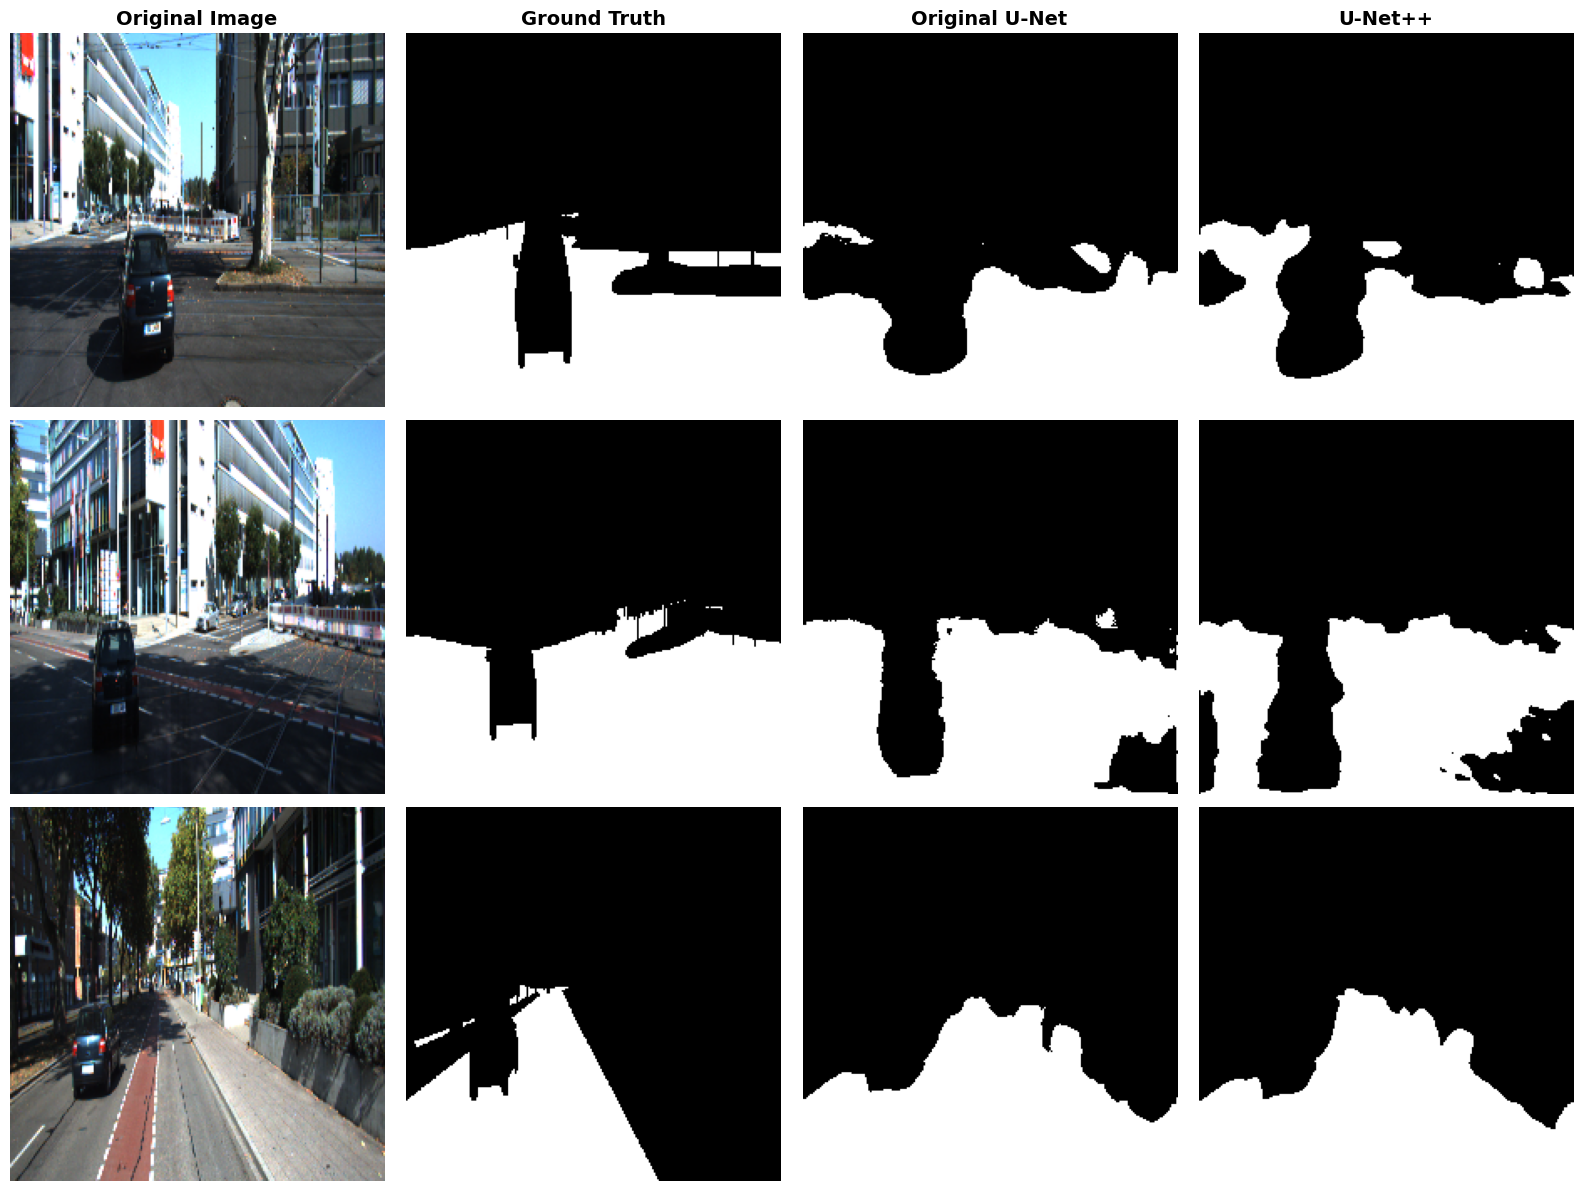

In [53]:
import matplotlib.pyplot as plt

# --- 1. 테스트를 위한 모델 인스턴스 생성 및 가중치 로드 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 두 모델 선언
model_unet = UNet(num_classes=1, input_channels=3).to(device)
model_unet_pp = UNetPlusPlus(num_classes=1, input_channels=3).to(device)

# 저장된 가중치 불러오기
model_unet.load_state_dict(torch.load('original_unet_kitti.pth', map_location=device))
model_unet_pp.load_state_dict(torch.load('unet_plus_plus_kitti.pth', map_location=device))

model_unet.eval()
model_unet_pp.eval()

# --- 2. 검증 데이터셋에서 시각화할 샘플 추출 ---
# val_loader(또는 test_dataset)에서 첫 번째 배치를 가져옵니다.
data_iter = iter(val_loader)
images, masks = next(data_iter)

# 추론 수행 (첫 3개 샘플만 시각화)
num_samples = min(3, images.size(0))
images_dev = images[:num_samples].to(device, dtype=torch.float32)

with torch.no_grad():
    outputs_unet = model_unet(images_dev)
    outputs_unet_pp = model_unet_pp(images_dev)
    
    # 시그모이드 및 임계값(0.5) 처리하여 이진 마스크 생성
    preds_unet = (torch.sigmoid(outputs_unet) > 0.5).float().cpu().numpy()
    preds_unet_pp = (torch.sigmoid(outputs_unet_pp) > 0.5).float().cpu().numpy()

# 이미지 플롯을 위해 넘파이 변환 (CHW -> HWC)
images_np = images[:num_samples].permute(0, 2, 3, 1).numpy()
masks_np = masks[:num_samples].squeeze(1).numpy()       # (B, 1, H, W) -> (B, H, W)
preds_unet = preds_unet.squeeze(1)
preds_unet_pp = preds_unet_pp.squeeze(1)

# --- 3. matplotlib를 이용한 4열 격자 시각화 ---
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

# 샘플이 1개일 때를 위한 예외 처리
if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

cols = ['Original Image', 'Ground Truth', 'Original U-Net', 'U-Net++']

for i in range(num_samples):
    # 1열: 원본 이미지 (Normalization 해제 필요 시 가감 가능, 여기서는 기본 출력)
    axes[i, 0].imshow(images_np[i])
    # 2열: 정답 마스크
    axes[i, 1].imshow(masks_np[i], cmap='gray')
    # 3열: 오리지널 U-Net 결과
    axes[i, 2].imshow(preds_unet[i], cmap='gray')
    # 4열: U-Net++ 결과
    axes[i, 3].imshow(preds_unet_pp[i], cmap='gray')
    
    # 타이틀 설정
    if i == 0:
        for col_idx, text in enumerate(cols):
            axes[i, col_idx].set_title(text, fontsize=14, fontweight='bold')
            
    for j in range(4):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()